In [1]:
#%%
# Imports
import numpy as np
import pylab as pl
import matplotlib.pyplot as plt
from sklearn import neighbors
from sklearn.model_selection import train_test_split
import pandas as pd
import requests
import seaborn as sns
import os

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# USGS live earthquake feed - all earthquakes from the last 24 hours
url = "https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/all_day.geojson"
response = requests.get(url)
data = response.json()

print("Status code:", response.status_code)
df = pd.json_normalize(data["features"])

print("Nombre de séismes:", len(df))

Status code: 200
Nombre de séismes: 211


In [3]:
# Extraction des coordonnées
df["longitude"] = df["geometry.coordinates"].apply(lambda x: x[0])
df["latitude"] = df["geometry.coordinates"].apply(lambda x: x[1])
df["depth_km"] = df["geometry.coordinates"].apply(lambda x: x[2])

# Colonnes utiles
df_clean = df[[
    "properties.mag",
    "properties.sig",
    "properties.nst",
    "properties.dmin",
    "properties.rms",
    "properties.gap",
    "longitude",
    "latitude",
    "depth_km"
]].copy()

df_clean.columns = [
    "magnitude",
    "significance",
    "nst",
    "dmin",
    "rms",
    "gap",
    "longitude",
    "latitude",
    "depth_km"
]

print(df_clean.shape)
df_clean.head()

(211, 9)


,magnitude,significance,nst,dmin,rms,gap,longitude,latitude,depth_km
0,0.22,1,8,0.01143,0.01,100,-122.807503,38.834667,2.04
1,1.81,50,37,0.00499,0.03,38,-122.814499,38.827000,1.81
2,2.21,75,35,0.03630,0.14,83,-155.403000,19.300833,29.73
3,0.76,9,35,0.07880,0.18,54,-117.216833,34.017333,14.35
4,2.97,136,24,0.12000,0.29,78,-115.093000,32.121500,19.13


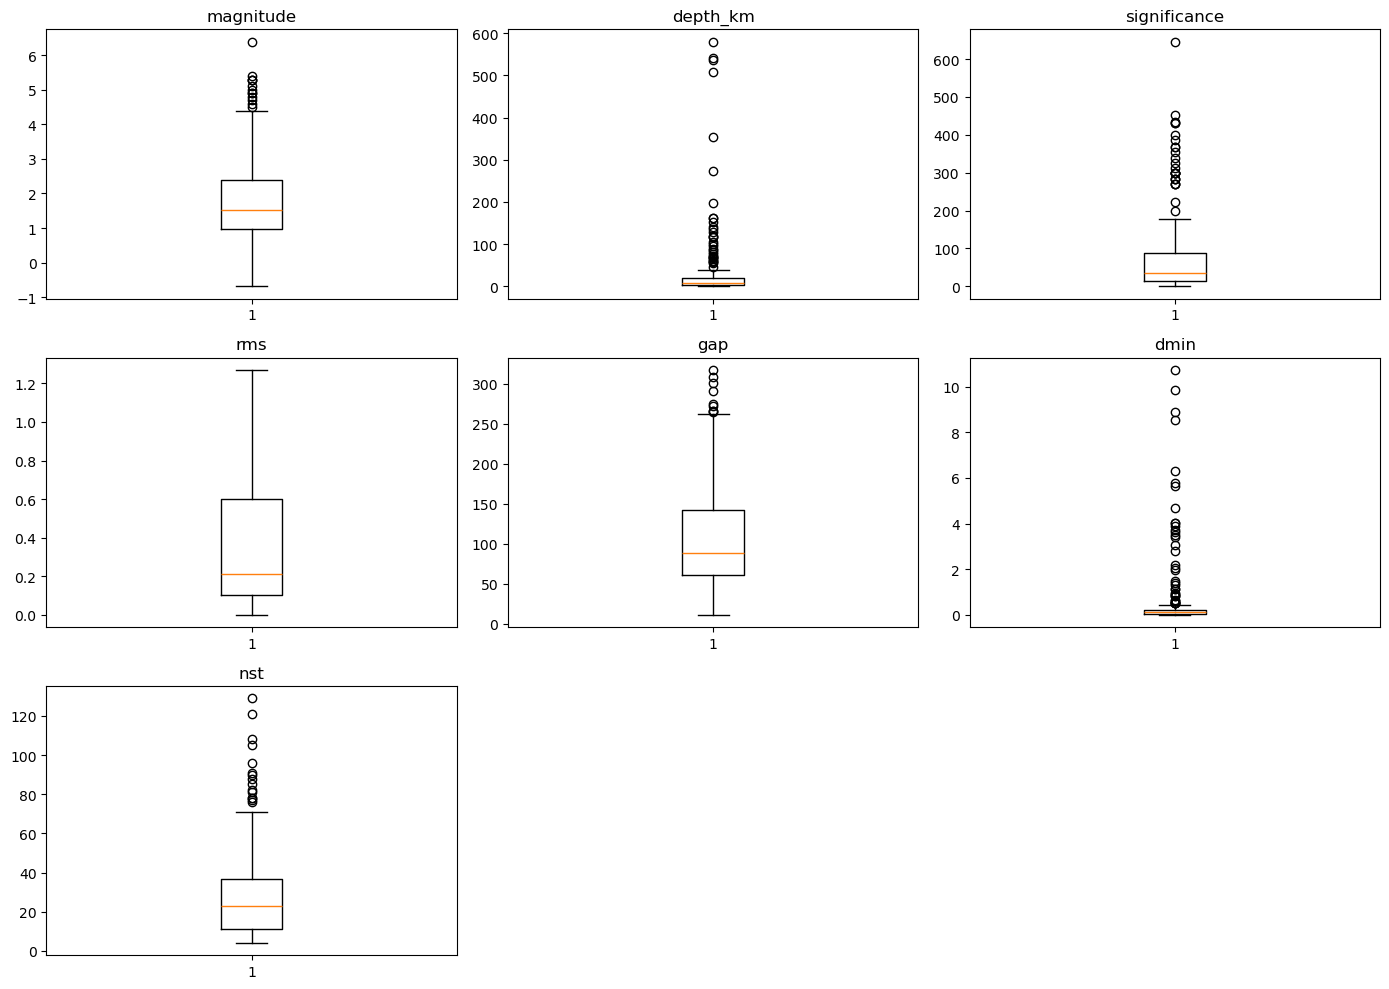

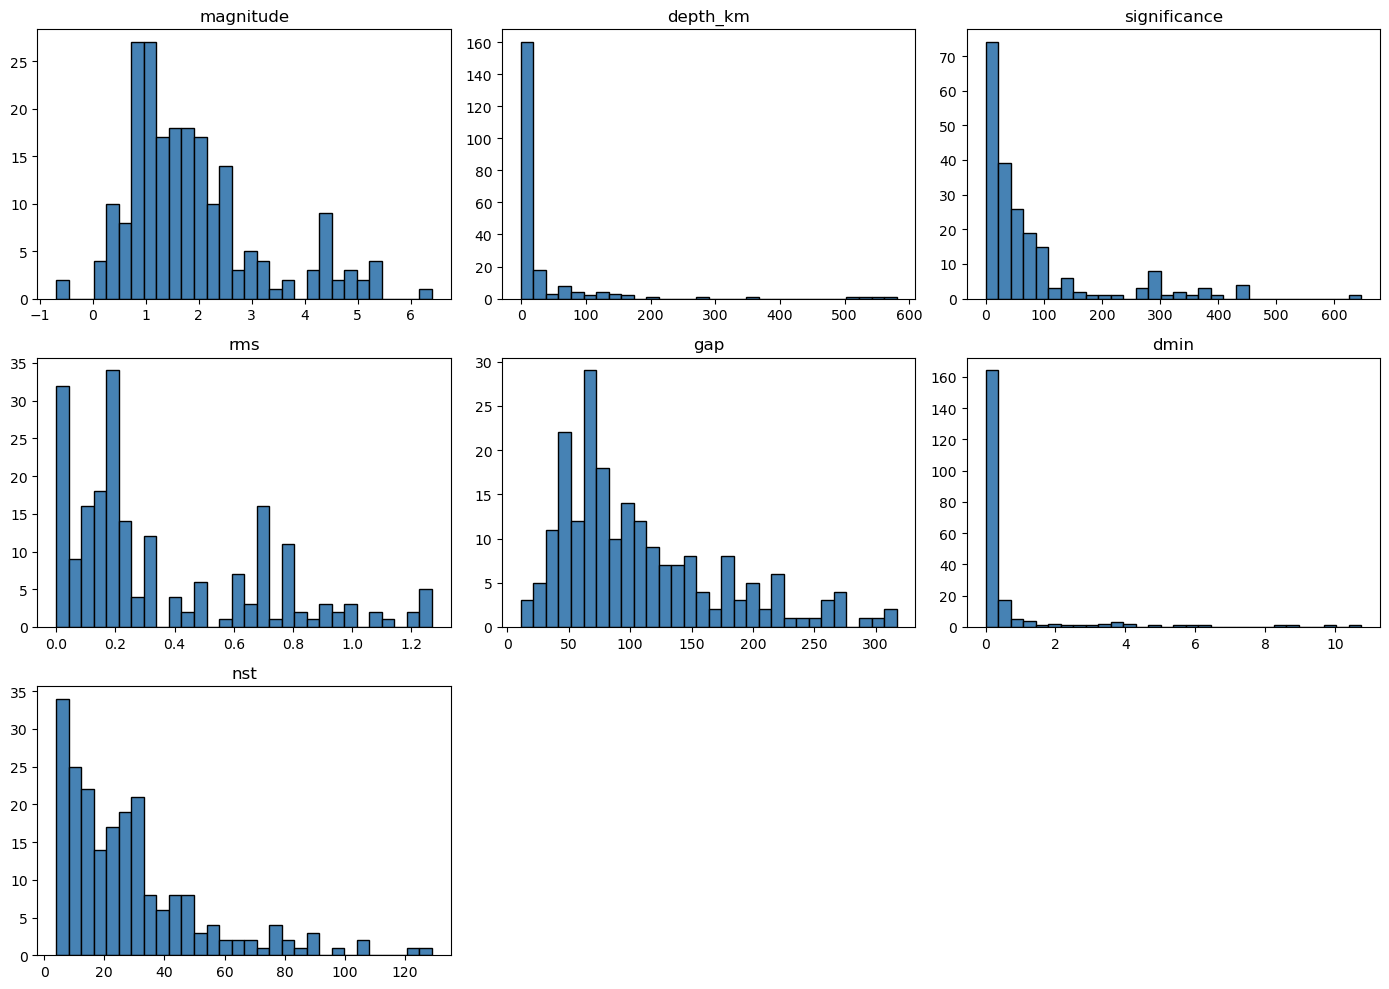

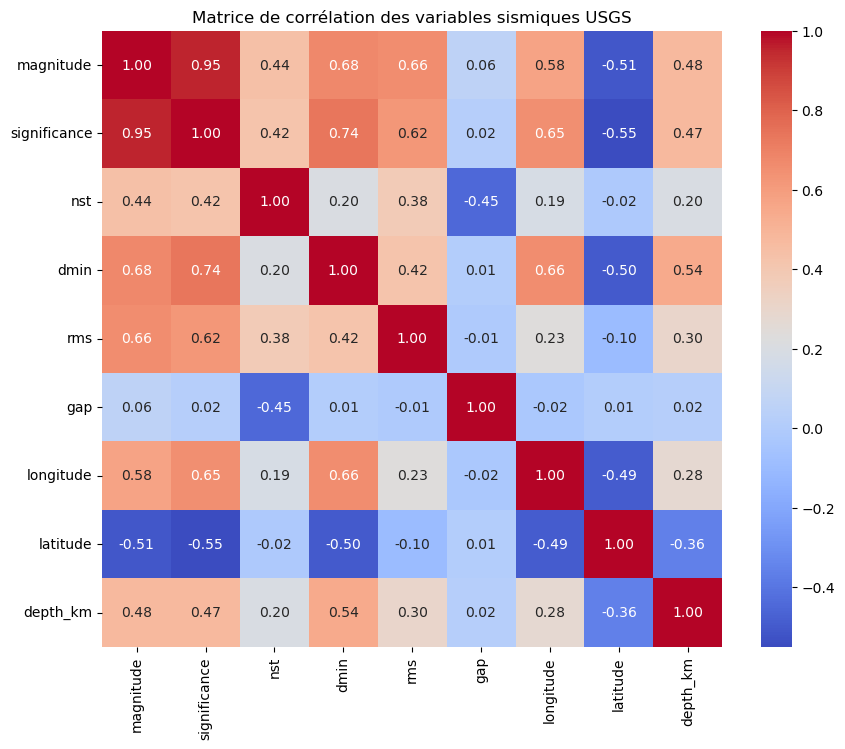

In [4]:
# Visualisations
variables = ["magnitude", "depth_km", "significance", "rms", "gap", "dmin", "nst"]

plt.figure(figsize=(14, 10))
for i, variable in enumerate(variables, 1):
    plt.subplot(3, 3, i)
    plt.boxplot(df_clean[variable].dropna())
    plt.title(variable)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 10))
for i, variable in enumerate(variables, 1):
    plt.subplot(3, 3, i)
    plt.hist(df_clean[variable].dropna(), bins=30, color='steelblue', edgecolor='black')
    plt.title(variable)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
corr = df_clean.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice de corrélation des variables sismiques USGS")
plt.show()

In [5]:
# Sauvegarde du dataset
os.makedirs("data", exist_ok=True)
df_clean.to_csv("data/03_Model_PGA.csv", index=False)
print("✅ Données sauvegardées dans data/03_Model_PGA.csv")

✅ Données sauvegardées dans data/03_Model_PGA.csv


In [6]:
# Préparation des données pour la régression
X = df_clean.drop(columns=["significance"])
y = df_clean["significance"]

print(X.shape)
print(y.shape)

(211, 8)
(211,)


In [7]:
# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=33
)

In [8]:
# Fonction d'évaluation des modèles
def evaluate_regression_model(name, y_true, y_pred, results):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    results[name] = {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R² Score": r2
    }

# Dictionnaire des résultats
results = {}

In [9]:
# 1. KNN Regression
knn = neighbors.KNeighborsRegressor(n_neighbors=15, weights='uniform')
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
evaluate_regression_model("KNN", y_test, y_pred_knn, results)

In [11]:
# 2. Decision Tree Regression
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
evaluate_regression_model("Decision Tree", y_test, y_pred_dt, results)

In [12]:
# 3. Random Forest Regression
rf = RandomForestRegressor(
    n_estimators=150,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
evaluate_regression_model("Random Forest", y_test, y_pred_rf, results)

print("Tous les modèles ont été entraînés et évalués.")

Tous les modèles ont été entraînés et évalués.


In [13]:
# Tableau comparatif des performances
df_results = pd.DataFrame(results).T
df_results = df_results.round(4)
print(df_results)


                   MAE        MSE     RMSE  R² Score
KNN            37.1082  4722.7348  68.7222    0.7026
Decision Tree   8.5660   997.9245  31.5899    0.9372
Random Forest   6.4147   925.3132  30.4190    0.9417


# Analyse Comparative et Choix du Meilleur Modèle (Régression)
Pourquoi se fier aux métriques d’erreur (MAE, RMSE) plutôt qu’au seul R² ?
Dans un problème de régression, le score R² peut parfois donner une impression trompeuse de performance, surtout lorsque la variable cible présente une forte variabilité ou des valeurs extrêmes.
Les métriques d’erreur comme :

MAE (Mean Absolute Error)

MSE (Mean Squared Error)

RMSE (Root Mean Squared Error)

mesurent directement l’écart entre les prédictions et les valeurs réelles. Elles permettent d’évaluer la précision réelle du modèle, indépendamment de la distribution de la cible.

👉 RMSE est particulièrement utile, car il pénalise davantage les grosses erreurs, ce qui est essentiel pour la prédiction de la sévérité des séismes

# Analyse des Algorithmes

1. KNN Regressor
Avantage :

Modèle simple, intuitif, sans hypothèse forte sur les données.

Fonctionne bien lorsque les points similaires sont proches dans l’espace des features.

Inconvénient :

Très sensible à l’échelle des variables et aux valeurs aberrantes.

Performances limitées lorsque les données sont dispersées ou bruitées.

Peut sous-performer sur des phénomènes géophysiques complexes comme les séismes.

2. Decision Tree Regressor
Avantage :

Capable de capturer des relations non linéaires.

Interprétable et rapide à entraîner.

Inconvénient :

Sujet au surapprentissage (overfitting).

Peut produire des prédictions instables si les données sont légèrement modifiées.

Moins performant sur des données continues avec forte variabilité.

3. Random Forest Regressor — 🏆 MEILLEUR CHOIX
Avantage :

Modèle d’ensemble robuste réduisant la variance des prédictions.

Gère bien les interactions complexes entre les variables sismiques (gap, dmin, rms, profondeur).

Moins sensible au bruit et aux valeurs extrêmes.

Performance :

Généralement le meilleur compromis entre faible erreur (MAE/RMSE) et bonne capacité de généralisation.

Capable de mieux capturer les relations géophysiques non linéaires que KNN ou un arbre simple.


⭐ Conclusion / Recommandation
Le Random Forest Regressor est retenu comme le meilleur modèle de régression pour prédire la sévérité (significance) des séismes.
Il offre :

la meilleure stabilité,

la meilleure précision globale,

la plus faible erreur moyenne,

et une meilleure capacité de généralisation sur des séismes non vus.

👉 C’est donc le modèle recommandé pour une utilisation opérationnelle ou pour une intégration dans un pipeline de monitoring sismique

In [15]:
#Sauvegarde du meilleur modèle

import joblib
os.makedirs("models", exist_ok=True)

model_path = os.path.join("models", "best_regressor_random_forest.pkl")
joblib.dump(rf, model_path)

print("Modèle sauvegardé avec succès.")
print("Emplacement :", model_path)


Modèle sauvegardé avec succès.
Emplacement : models\best_regressor_random_forest.pkl
